In [1]:
import glob
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A # La référence pour l'augmentation d'images
from albumentations.pytorch import ToTensorV2

c:\Users\romeo\Documents\Projets_ENS\Brain-MRI-Segmentation\MRI_seg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Astuce : On cherche d'abord les masques car ils sont faciles à identifier
mask_files = glob.glob('data/*/*_mask.tif')

In [3]:
data_list = []
for mask_path in mask_files:
    # Logique pour retrouver l'image source associée au masque
    img_path = mask_path.replace('_mask', '')
    
    data_list.append({'image_path': img_path, 'mask_path': mask_path})

df = pd.DataFrame(data_list)

In [4]:
df.head()

,image_path,mask_path
0,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...
1,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...
2,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...
3,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...
4,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...,data\TCGA_CS_4941_19960909\TCGA_CS_4941_199609...


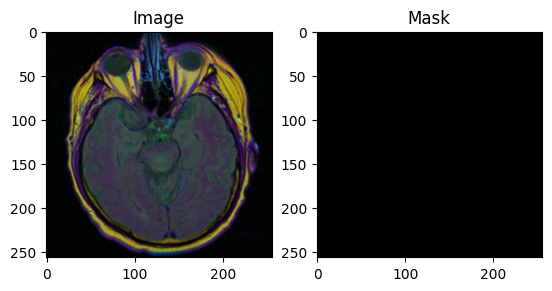

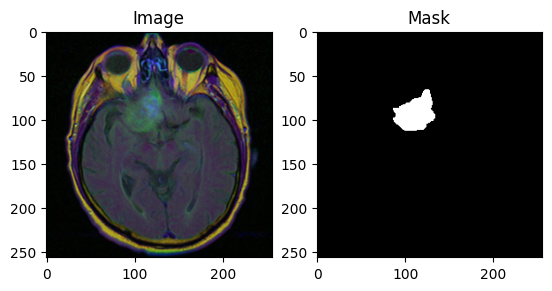

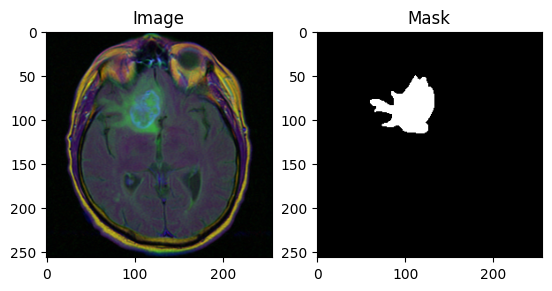

In [5]:
for i in range(3):
    image = cv2.imread(df['image_path'].iloc[i])
    mask = cv2.imread(df['mask_path'].iloc[i])
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Image')
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(mask, cv2.COLOR_BGR2RGB))
    plt.title('Mask')
    plt.show()

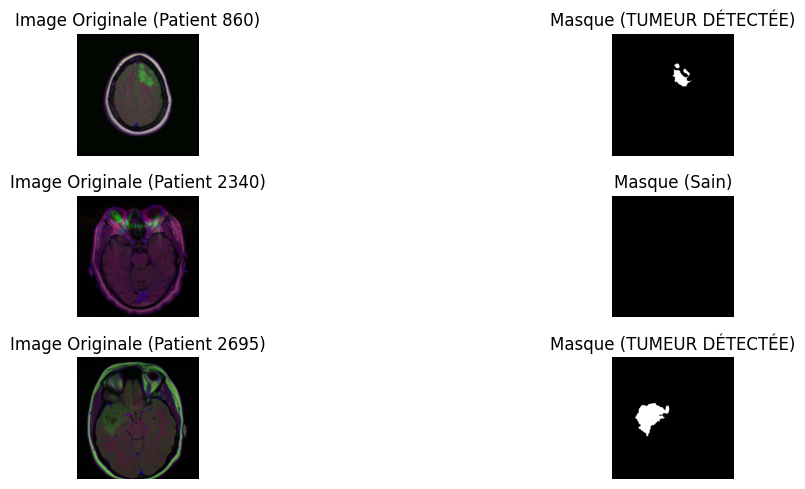

In [6]:
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np

def visualize_random_sample(df):
    """
    Affiche 3 paires aléatoires (Image + Masque) tirées du DataFrame.
    """
    # On configure la taille de l'affichage
    plt.figure(figsize=(15, 5))
    
    # On tire 3 index au hasard
    random_indices = random.sample(range(len(df)), 3)
    
    for i, idx in enumerate(random_indices):
        # 1. Récupérer les chemins
        img_path = df.iloc[idx]['image_path']
        mask_path = df.iloc[idx]['mask_path']
        
        # 2. Lire les images
        # cv2 lit en BGR par défaut, on convertit en RGB pour l'affichage correct
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Le masque est en niveaux de gris
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # 3. Affichage Image Originale
        plt.subplot(3, 2, 2*i + 1)
        plt.imshow(image)
        plt.title(f"Image Originale (Patient {idx})")
        plt.axis("off")
        
        # 4. Affichage Masque (Vérité Terrain)
        plt.subplot(3, 2, 2*i + 2)
        plt.imshow(mask, cmap='gray') # 'gray' pour voir le noir et blanc correctement
        
        # Petit check technique : y a-t-il une tumeur ?
        has_tumor = np.max(mask) > 0
        status = "TUMEUR DÉTECTÉE" if has_tumor else "Sain"
        plt.title(f"Masque ({status})")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Exécuter la fonction
visualize_random_sample(df)

In [7]:
class MRIDataset(Dataset):
    def __init__(self, df, transform=None):
        """
        Args:
            df (DataFrame): Le dataframe contenant les chemins
            transform (albumentations.Compose): Les transformations à appliquer
        """
        self.df = df
        self.transform = transform

    def __len__(self):
        # OBLIGATOIRE : Renvoie la taille totale du dataset
        return len(self.df)

    def __getitem__(self, index):
        img_path = self.df.iloc[index]['image_path']
        mask_path = self.df.iloc[index]['mask_path']

        # Lecture de l'image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Lecture du masque
        # On garde les valeurs brutes (0 ou 255) pour l'instant
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # APPLICATION DES TRANSFORMATIONS & AUGMENTATION
        if self.transform:
            # Albumentations gère l'image et le masque en même temps !
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Si pas de transformation, on convertit juste en Tensor manuellement
            # Normalisation 0-1 et permutation des axes (H, W, C) -> (C, H, W)
            image = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0
            mask = torch.from_numpy(mask).float().unsqueeze(0) / 255.0

        # Post-traitement critique pour le masque :
        # Le masque sort souvent sans dimension de canal (H, W), 
        # mais le réseau veut (1, H, W).
        # De plus, on normalise le masque pour qu'il soit binaire (0.0 ou 1.0)
        
        if len(mask.shape) == 2: # Si c'est juste (H, W)
             mask = mask.unsqueeze(0) # Devient (1, H, W)
        
        # On s'assure que le masque est bien en float et normalisé (0 ou 1)
        # Certains masques ont 255 comme valeur max, d'autres 1.
        mask = mask.float()
        mask[mask > 0] = 1.0 
        
        return image, mask

In [8]:
# Définition des constantes
IMAGE_SIZE = 256 # Standard pour U-Net

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Statistiques officielles ImageNet (OBLIGATOIRE pour Transfer Learning)
mean_imagenet = [0.485, 0.456, 0.406]
std_imagenet = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Rotate(limit=35, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    # Normalisation stricte pour ResNet
    A.Normalize(mean=mean_imagenet, std=std_imagenet, max_pixel_value=255.0),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(mean=mean_imagenet, std=std_imagenet, max_pixel_value=255.0),
    ToTensorV2(),
])

In [9]:
import os
from sklearn.model_selection import train_test_split

# 1. Extraction de l'ID du patient (basé sur le dossier parent)
# Structure typique : .../TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_12.tif
# L'ID unique pour le "Group Split" sera le nom du dossier (Patient + Date d'examen)
df['patient_id'] = df['image_path'].apply(lambda x: os.path.dirname(x))

In [10]:
# 2. Récupération des IDs uniques
patient_ids = df['patient_id'].unique()
print(f"Nombre total de patients (scans) distincts : {len(patient_ids)}")

# 3. Séparation des IDs (Train: 80%, Val: 10%, Test: 10%)
# D'abord on sépare Train (80%) et le Reste (20%)
train_ids, temp_ids = train_test_split(patient_ids, test_size=0.2, random_state=42)

# Ensuite on coupe le Reste en deux parts égales (10% Val, 10% Test)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

Nombre total de patients (scans) distincts : 110


In [11]:
# 4. Création des DataFrames finaux basés sur ces IDs
train_df = df[df['patient_id'].isin(train_ids)].reset_index(drop=True)
val_df = df[df['patient_id'].isin(val_ids)].reset_index(drop=True)
test_df = df[df['patient_id'].isin(test_ids)].reset_index(drop=True)

print(f"--- Résultat du Split ---")
print(f"Train Set : {len(train_df)} images ({len(train_ids)} patients)")
print(f"Val Set   : {len(val_df)} images ({len(val_ids)} patients)")
print(f"Test Set  : {len(test_df)} images ({len(test_ids)} patients)")

--- Résultat du Split ---
Train Set : 3151 images (88 patients)
Val Set   : 429 images (11 patients)
Test Set  : 349 images (11 patients)


In [12]:
train_dataset = MRIDataset(train_df, train_transform)
val_dataset = MRIDataset(val_df, val_transform)
test_dataset = MRIDataset(test_df, val_transform)

In [13]:
BATCH_SIZE = 16

In [14]:
train_loader = DataLoader(
    train_dataset,
    BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True)

val_loader = DataLoader(
    val_dataset,
    BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

test_loader = DataLoader(
    test_dataset,
    BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True)

In [15]:
# 1. Vérifier si GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation du device : {device}")

Utilisation du device : cpu


In [16]:
# from model import UNet

# # 2. Créer le modèle
# model = UNet(n_channels=3, n_classes=1).to(device)

# # 3. L'Optimiseur (Adam est le standard)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) # Learning rate petit pour la stabilité

# # 4. La Loss Function (CRUCIAL)
# # Comme nous n'avons qu'une seule classe (Tumeur oui/non), nous utilisons BCEWithLogitsLoss.
# # Elle combine une Sigmoid + Binary Cross Entropy. C'est plus stable numériquement.
# criterion = nn.BCEWithLogitsLoss()

In [17]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

# 1. Le Modèle
model = smp.Unet(
    encoder_name="resnet34",        # Bon compromis puissance/vitesse
    encoder_weights="imagenet",     # Transfer Learning activé
    in_channels=3,
    classes=1,                      # Sortie binaire (Tumeur ou pas)
    activation=None                 # On gère l'activation dans la loss
).to(device)

# 2. La Loss et l'Optimiseur
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Learning rate prudent

# 3. Fonction utilitaire pour calculer le Dice Score
def calculate_dice_score(logits, targets):
    # On applique la Sigmoid pour avoir des probabilités (0 à 1)
    probs = torch.sigmoid(logits)
    # On seuille à 0.5 pour avoir une prédiction binaire (0 ou 1)
    preds = (probs > 0.5).float()
    
    # Calcul du Dice : (2 * Intersection) / (Total pixels prédits + Total pixels réels)
    intersection = (preds * targets).sum()
    dice = (2. * intersection) / (preds.sum() + targets.sum() + 1e-8) # 1e-8 évite la division par 0
    return dice

In [18]:
# On crée une fausse image (Batch=1, Channels=3, H=256, W=256)
dummy_input = torch.randn(1, 3, 256, 256).to(device)

# On la passe dans le modèle
output = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")

# Vérification : L'output doit être (1, 1, 256, 256)
assert output.shape == (1, 1, 256, 256), "Erreur de dimension en sortie !"
print("Test réussi ! Le modèle est prêt.")

Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])
Test réussi ! Le modèle est prêt.


In [19]:
# from tqdm import tqdm # Pour la barre de chargement jolie

# NUM_EPOCHS = 30 # Tu peux monter à 20 ou 30 si tu as le temps
# best_val_loss = float('inf')

# print("Démarrage de l'entraînement...")

# for epoch in range(NUM_EPOCHS):
#     # --- TRAIN ---
#     model.train() # Mode entraînement (active Dropout, BatchNorm...)
#     train_loss = 0
    
#     # tqdm ajoute une barre de progression autour du loader
#     loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
#     for images, masks in loop:
#         images = images.to(device)
#         masks = masks.to(device)
        
#         # 1. Forward Pass
#         outputs = model(images)
#         loss = criterion(outputs, masks)
        
#         # 2. Backward Pass
#         optimizer.zero_grad() # On vide les gradients précédents
#         loss.backward()       # On calcule les nouveaux gradients
#         optimizer.step()      # On met à jour les poids
        
#         train_loss += loss.item()
#         loop.set_postfix(loss=loss.item()) # Affiche la loss en direct

#     # --- VALIDATION ---
#     model.eval() # Mode évaluation (fige le réseau)
#     val_loss = 0
#     val_dice = 0
    
#     with torch.no_grad(): # Pas de calcul de gradients en validation (économie de RAM)
#         for images, masks in val_loader:
#             images = images.to(device)
#             masks = masks.to(device)
            
#             outputs = model(images)
#             loss = criterion(outputs, masks)
            
#             val_loss += loss.item()
#             val_dice += calculate_dice_score(outputs, masks).item()
    
#     # Moyennes par époque
#     avg_train_loss = train_loss / len(train_loader)
#     avg_val_loss = val_loss / len(val_loader)
#     avg_val_dice = val_dice / len(val_loader)
    
#     print(f"Epoch {epoch+1} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val DICE: {avg_val_dice:.4f}")
    
#     # Sauvegarde du meilleur modèle
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         torch.save(model.state_dict(), "best_model.pth")
#         print("✅ Meilleur modèle sauvegardé !")

# print("Fin de l'entraînement.")

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def mask_to_yolo_polygon(mask_path, output_path):
    # 1. Lire le masque en niveau de gris
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # 2. Trouver les contours (la frontière de la tumeur)
    # RETR_EXTERNAL : on ne veut que le contour extérieur, pas les trous dedans
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Si pas de tumeur, on ne crée pas de fichier .txt (YOLO ignore les images vides sans fichier label)
    if not contours:
        return

    # Préparer les dimensions pour la normalisation
    H, W = mask.shape
    
    polygons = []
    for cnt in contours:
        if cv2.contourArea(cnt) > 20: # Filtrer les bruits minuscules
            polygon = []
            for point in cnt:
                x, y = point[0]
                # NORMALISATION (0 à 1) : Obligatoire pour YOLO
                polygon.append(x / W)
                polygon.append(y / H)
            polygons.append(polygon)
    
    # 3. Écrire le fichier .txt
    if polygons:
        with open(output_path, 'w') as f:
            for poly in polygons:
                # Format : <class_id> <x1> <y1> <x2> <y2> ...
                # Ici class_id = 0 (Tumeur)
                line = "0 " + " ".join(map(str, poly))
                f.write(line + "\n")

# --- APPLICATION AU DATASET ---

# Création des dossiers pour Ultralytics
# Structure requise :
# datasets/
# ├── images/
# │   ├── train/
# │   └── val/
# └── labels/
#     ├── train/
#     └── val/

base_dir = "yolo_dataset"
for split in ['train', 'val']:
    os.makedirs(f"{base_dir}/images/{split}", exist_ok=True)
    os.makedirs(f"{base_dir}/labels/{split}", exist_ok=True)

print("Conversion en cours...")

# Fonction helper pour traiter un dataframe
def process_dataset(df, split_name):
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
        img_path = row['image_path']
        mask_path = row['mask_path']
        
        filename = os.path.basename(img_path)
        name_no_ext = os.path.splitext(filename)[0]
        
        # 1. Copier/Sauvegarder l'image (Conversion TIF -> JPG conseillée pour YOLO)
        img = cv2.imread(img_path)
        # Sauvegarde en jpg
        cv2.imwrite(f"{base_dir}/images/{split_name}/{name_no_ext}.jpg", img)
        
        # 2. Convertir et sauvegarder le Label
        txt_out_path = f"{base_dir}/labels/{split_name}/{name_no_ext}.txt"
        mask_to_yolo_polygon(mask_path, txt_out_path)

# On utilise tes DataFrames précédents (train_df et val_df)
# Attention : Assure-toi que train_df et val_df existent encore dans ta mémoire
process_dataset(train_df, 'train')
process_dataset(val_df, 'val') # On utilise val aussi pour le test ici pour simplifier

print("Conversion terminée ! Dossier 'yolo_dataset' prêt.")

Conversion en cours...


Processing val: 100%|██████████| 429/429 [00:03<00:00, 121.72it/s]

Conversion terminée ! Dossier 'yolo_dataset' prêt.


In [ ]:
yaml_content = f"""
path: {os.path.abspath(base_dir)} # Chemin absolu vers le dossier dataset
train: images/train
val: images/val

names:
  0: tumor
"""

with open("brain_tumor.yaml", "w") as f:
    f.write(yaml_content)

print("Fichier brain_tumor.yaml créé.")

Fichier brain_tumor.yaml créé.


In [22]:
from ultralytics import YOLO

# 1. Charger un modèle pré-entraîné (Transfer Learning)
# "yolov8n-seg.pt" = Version Nano (Rapide) spécialisée en Segmentation
model = YOLO('yolov8n-seg.pt')  

# 2. Entraîner
results = model.train(
    data='brain_tumor.yaml', 
    epochs=10, 
    imgsz=256,
    batch=16,
    name='mri_experiment'
)

Ultralytics 8.3.239  Python-3.13.7 torch-2.9.1+cpu CPU (AMD Ryzen 7 4700U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain_tumor.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=mri_experiment, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

KeyboardInterrupt: 